# **Importation des Bibliotheques**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score,classification_report,confusion_matrix,roc_auc_score)
import joblib 

# **Charger les données nettoyées**
**je charge le fichier que j'ai nettoyer dans l'EDA**

In [2]:
donnees = pd.read_csv("../data/diabetes_clean.csv")
print(f"{donnees.shape[0]} lignes  et {donnees.shape[1]} colonnes")
donnees

768 lignes  et 9 colonnes


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,125,33.6,0.627,50,1
1,1,85,66,29,125,26.6,0.351,31,0
2,8,183,64,29,125,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,125,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,29,125,30.1,0.349,47,1


# **Separer les features (X) des targets (Y)**<br>
**X ce qu'on donne au model en entrée (toutes les colonnnes medicales sauf le resultats)<br> et Y ce qu'on donne que le model predise en sortie (uniquement la colonne Outcome ou 0-non diabetique et 1=diabetique)**

In [3]:
# X
variables_medicales = donnees.drop("Outcome",axis=1)

# Y
resultat_diabete = donnees["Outcome"]

print(" separation fait")
print(f"{variables_medicales}")
resultat_diabete


 separation fait
     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      148             72             35      125  33.6   
1              1       85             66             29      125  26.6   
2              8      183             64             29      125  23.3   
3              1       89             66             23       94  28.1   
4              0      137             40             35      168  43.1   
..           ...      ...            ...            ...      ...   ...   
763           10      101             76             48      180  32.9   
764            2      122             70             27      125  36.8   
765            5      121             72             23      112  26.2   
766            1      126             60             29      125  30.1   
767            1       93             70             31      125  30.4   

     DiabetesPedigreeFunction  Age  
0                       0.627   50  
1                   

0      1
1      0
2      1
3      0
4      1
      ..
763    0
764    0
765    0
766    1
767    0
Name: Outcome, Length: 768, dtype: int64

# **decoupages des donnee d'entrainement et de test**
**le model va apprend sur le train et je vais verifier ses resultas sur le test**

In [4]:
X_train, X_test, y_train, y_test = train_test_split(variables_medicales, resultat_diabete, test_size=0.2, random_state=42,stratify=resultat_diabete)

print(f" Entrainement: {X_train.shape[0]} patient (80)%")
print(f" Test: {X_test.shape[0]} patient (20)%")
print(f"\n repartition dans test:")
print(f" Non Diabetique: {(y_test==0).sum()}")
print(f" Diabetique: {(y_test==1).sum()}")


 Entrainement: 614 patient (80)%
 Test: 154 patient (20)%

 repartition dans test:
 Non Diabetique: 100
 Diabetique: 54


# **Normalisation des donnees**
**sans la normalisation le model pense que d'autres colonnes sont plus importantes que d'autres juste parceque les chiffres sont plus grands or ce n'est pas logique**<br>
**Apres la normalisation, toutes les variables sont sur la même echelle donc le model peut les comparer equitablement**

In [5]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

# **Entrainement des 3 modeles**<br>
**creation de modele qu'on va comparer,Chaque modele une facon differente d'apprendre**<br>
**Modele1: Regression Logistique<br>Model2: Random Forest<br>Model3: SVM Support Vector Machine**

**model1: ces le plus simple,il trace une ligne de separation entre les diabetique et les non diabetique,il est rapide a entrainer et facile a interpreter<br>model2: cree plusieurs arbres de decision et vote pour la meilleur prediction(c'est comme demmander l'avis de 100 medecins et prendre la decision de la majoriter)<br>model3: trouve la frontiere Mathematique etre les deus groupes,on veut juste le % de risques**

In [6]:
model_lr = LogisticRegression(random_state=42, max_iter=1000)
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
model_svm = SVC(probability=True, random_state=42)

model_lr.fit(X_train_scaled, y_train)
model_rf.fit(X_train_scaled, y_train)
model_svm.fit(X_train_scaled, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


# **Evaluation des metrics de performances des 3 model**

In [7]:
listes_modeles = [("LogisticRegression", model_lr), ("RandomForestClassifier",model_rf) , ("SVM",model_svm)]

resultats ={}

for nom_modele, modele in listes_modeles:
    predictions = modele.predict(X_test_scaled)
    probabilites = modele.predict_proba(X_test_scaled)[:, 1]                                                       #garde uniquemnt la probabilites d'etre diabetique
    accuracy = accuracy_score(y_test, predictions)
    auc =roc_auc_score(y_test, probabilites)
    
    resultats[nom_modele]={
        "accuracy": accuracy,
        "auc": auc,
        "predictions": predictions
    }
    
    print(f"\n {nom_modele}")
    print(f" Accuracy : {accuracy *100:.1f}%\n AUC: {auc:.3f} ")
    
    


 LogisticRegression
 Accuracy : 70.8%
 AUC: 0.813 

 RandomForestClassifier
 Accuracy : 77.9%
 AUC: 0.818 

 SVM
 Accuracy : 74.0%
 AUC: 0.796 


# **Visualiser les resultats**<br>
**comparaisons des modeles**

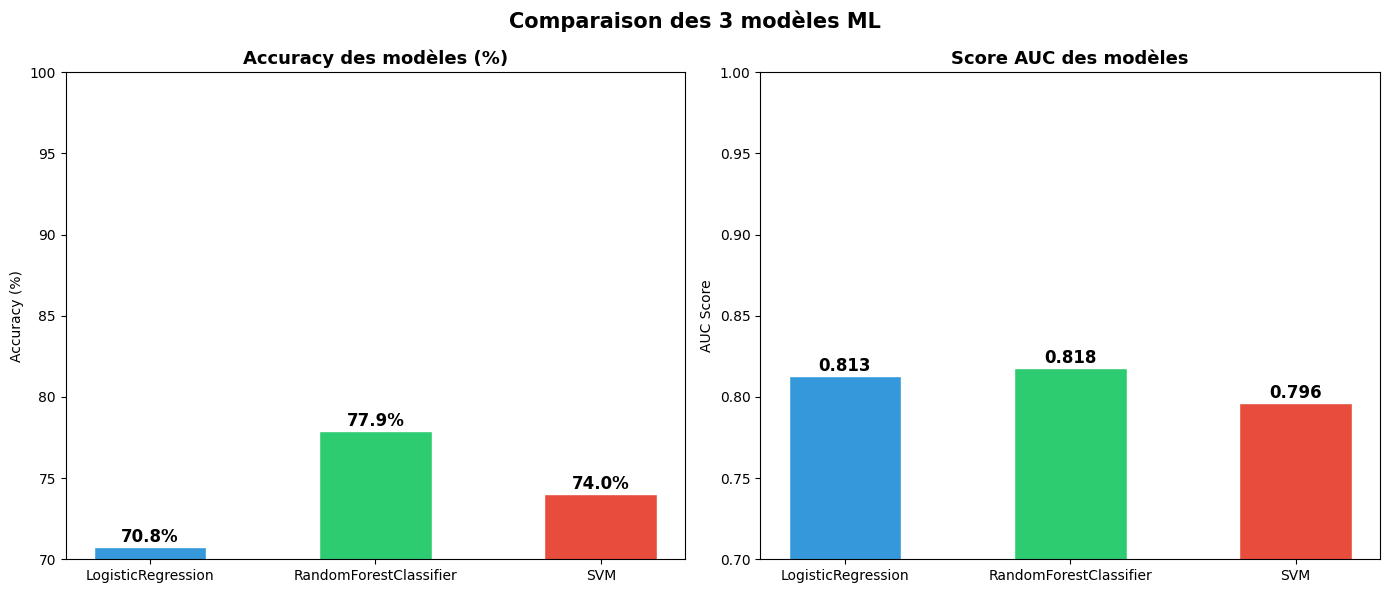

In [8]:
noms = list(resultats.keys())
acc = [resultats[m]["accuracy"]*100 for m in noms]
auc = [resultats[m]['auc'] for m in noms]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
barres = axes[0].bar(                      
    noms, acc,
    color=["#3498DB", "#2ECC71", "#E74C3C"],
    edgecolor="white",
    width=0.5
)
axes[0].set_title("Accuracy des modèles (%)",
                   fontsize=13, fontweight="bold")
axes[0].set_ylabel("Accuracy (%)")
axes[0].set_ylim([70, 100])

for barre, valeur in zip(barres, acc):
    axes[0].text(
        barre.get_x() + barre.get_width() / 2,
        barre.get_height() + 0.3,
        f"{valeur:.1f}%",
        ha="center", fontweight="bold", fontsize=12
    )
    
barres2 = axes[1].bar(                                  
    noms, auc,
    color=["#3498DB", "#2ECC71", "#E74C3C"],
    edgecolor="white",
    width=0.5
)
axes[1].set_title("Score AUC des modèles",
                   fontsize=13, fontweight="bold")
axes[1].set_ylabel("AUC Score")
axes[1].set_ylim([0.7, 1.0])

for barre, valeur in zip(barres2, auc):
    axes[1].text(
        barre.get_x() + barre.get_width() / 2,
        barre.get_height() + 0.003,
        f"{valeur:.3f}",
        ha="center", fontweight="bold", fontsize=12
    )

plt.suptitle("Comparaison des 3 modèles ML",
             fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

# **Matrice de confusion des 3 modeles**<br>
**la matrice va nous montrer en detail ou le model se trompe**

**-Vrai Négatif  : non diabétique prédit non diabétique <br>-Vrai Positif  : diabétique prédit diabétique<br>-Faux Positif  : non diabétique prédit diabétique (fausse alerte)<br>-Faux Négatif  : diabétique prédit non diabétique (le plus dangereux !)**

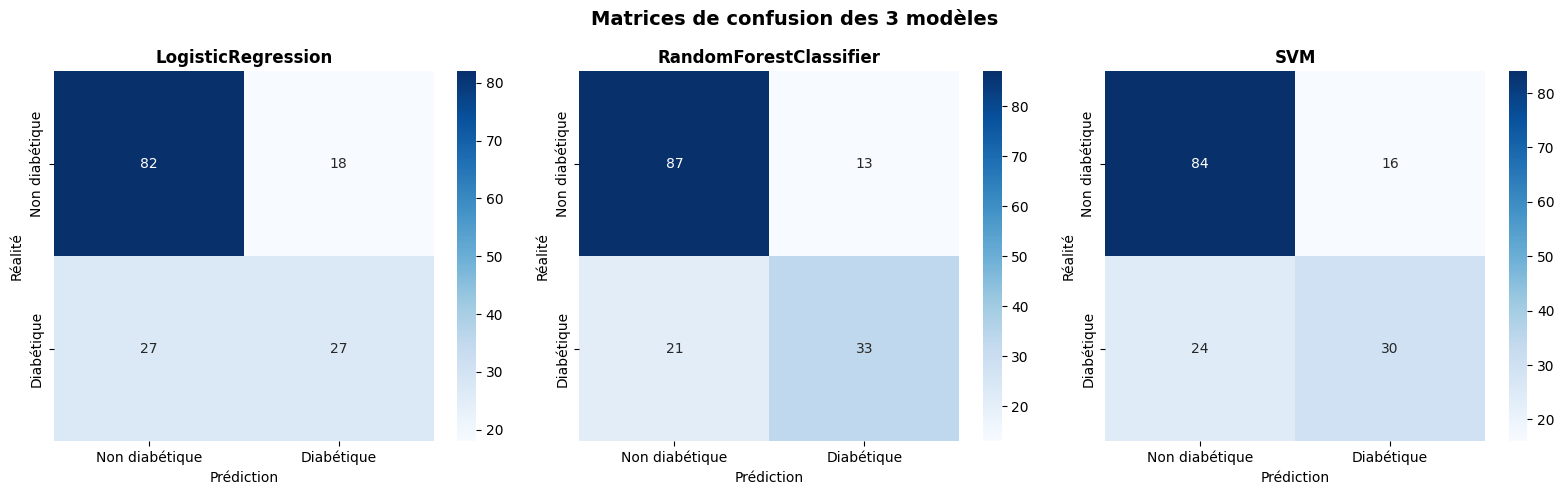

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, (nom_modele, modele) in enumerate(listes_modeles):
    predictions = resultats[nom_modele]['predictions']
    matrice =confusion_matrix(y_test, predictions)
    
    sns.heatmap(
        matrice,
        annot=True, 
        fmt="d", 
        cmap="Blues", 
        ax=axes[i],
        xticklabels=["Non diabétique", "Diabétique"],
        yticklabels=["Non diabétique", "Diabétique"]
    )
    axes[i].set_title(f"{nom_modele}", fontsize=12, fontweight="bold")
    axes[i].set_ylabel("Réalité")
    axes[i].set_xlabel("Prédiction")

plt.suptitle("Matrices de confusion des 3 modèles", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()
    
    

# **Choisir le meilleur modele**<br>
**on choisir le modele avec le meilleur score AUC,car l'AUC mesure mieux la qualite globale qu'un %**

In [10]:
meilleur_nom = None
meilleur_auc =0

for nom_modele in resultats:
    accuracy = resultats[nom_modele]["accuracy"] *100
    auc = resultats[nom_modele]['auc']
    
    if auc> meilleur_auc:
        meilleur_auc = auc
        meilleur_nom = nom_modele
        
    print(f"\n {nom_modele}")
    print(f" Accuracy : {accuracy:.1f}%")
    print(f" AUC: {auc:.3f}")
    
print(f"\n Modele : {meilleur_nom}")
print(f" AUC: {meilleur_auc:.3f}")
modeles_dict = { "LogisticRegression" : model_lr, "RandomForestClassifier" : model_rf, "SVM" : model_svm}
meilleur_modele = modeles_dict[meilleur_nom]



 LogisticRegression
 Accuracy : 70.8%
 AUC: 0.813

 RandomForestClassifier
 Accuracy : 77.9%
 AUC: 0.818

 SVM
 Accuracy : 74.0%
 AUC: 0.796

 Modele : RandomForestClassifier
 AUC: 0.818


# **Sauvegarde du Model et du scaler**<br>
**on sauvegarde le meilleur modele dans un fichier .pkl,ce fichier sera charger par le dashboard streamlit pour faire des prediction en temps reel**

In [11]:
joblib.dump(meilleur_modele, "../model/meilleur_modele.pkl")
print(f"Modele '{meilleur_nom}' sauvegarder")
joblib.dump(scaler, "../model/scaler.pkl")
print("sacaler sauvegarder avec succes !!!!!!!!!!")

Modele 'RandomForestClassifier' sauvegarder
sacaler sauvegarder avec succes !!!!!!!!!!


# **Conclusion**<br>
j'ai entrainer et comparer 3 modeles de ML:
-**LogisticRegression**: modele simple et rapide<br>
-**RandomForestClassifier**:ensemble de 100 arbres de decision<br>
-**SVM**: frontière mathemathique entre les deux groupes (diabetique et non diabetique)
le meilleur modele a ete selectionne sur la base du **score AUC** car il mesure mieux la qualite globale qu'un simple pourcentage.<br>
le modele et le sacaler ont ete sauvegarder dans '/model' et seront utilises par le dashboard Streamlit pour faire des predictions en temps reel.
